# Predicting Student Exam Scores Using Regression Models

## Mission
This project is trying to predict how well a student will score on their exam based on things like how many hours they study, their attendance, whether their parents are involved and other factors. the idea is that if we can predict low scores early, teachers can step in and help those students before it is too late

The dataset that was used is the **Student Performance Factors** dataset from Kaggle, it has about 6607 rows and 20 columns covering a mix of numeric and categorical features like study hours, sleep, motivation level, internet access, and parental education, the target column that I will be trying to predict is ```Exam Score```
Dataset source: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors
Models being used: linear regression, decision tree regressor, and random forest regressor, all from scikit-learn



## 1. importing the libraries i need

In [1]:
# importing the tools i need for splitting data, scaling, and the models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

## 2. loading the dataset

In [2]:
# loadingthe csv
df = pd.read_csv('StudentPerformanceFactors.csv')

print('shape of the dataset:', df.shape)
print('columns:', list(df.columns))
df.head()

shape of the dataset: (6607, 20)
columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 3. exploring the data

In [3]:
# separating columns into categorical and numeric for encoding
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

### looking at the distribution of exam scores

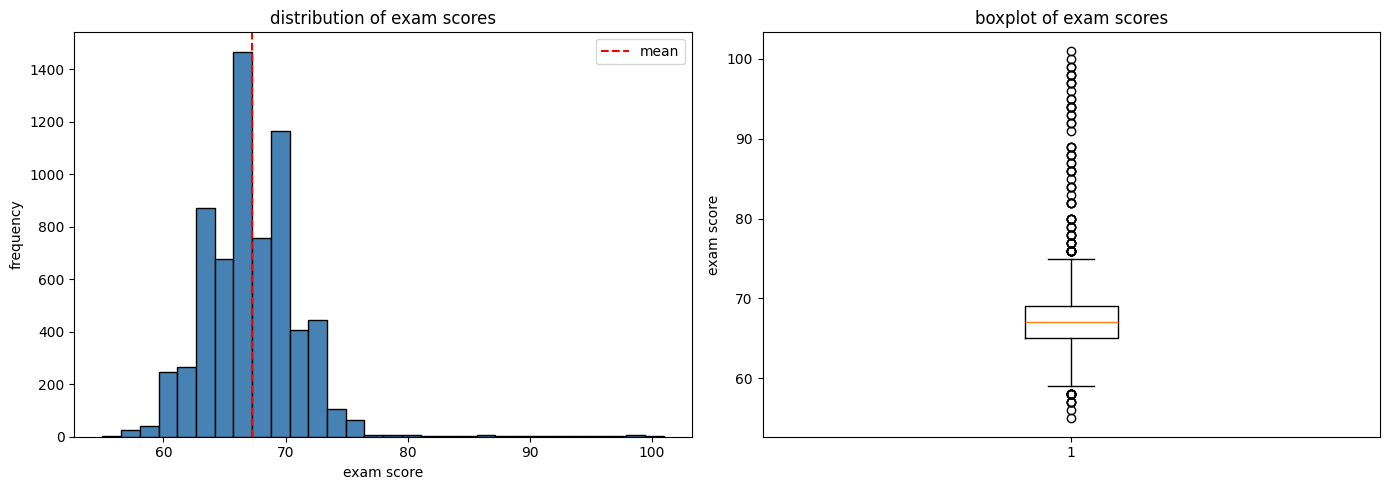

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Exam_Score'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('distribution of exam scores')
axes[0].set_xlabel('exam score')
axes[0].set_ylabel('frequency')
axes[0].axvline(df['Exam_Score'].mean(), color='red', linestyle='--', label='mean')
axes[0].legend()
axes[1].boxplot(df['Exam_Score'])
axes[1].set_title('boxplot of exam scores')
axes[1].set_ylabel('exam score')
plt.tight_layout()
plt.show()

### correlation heatmap for numeric features

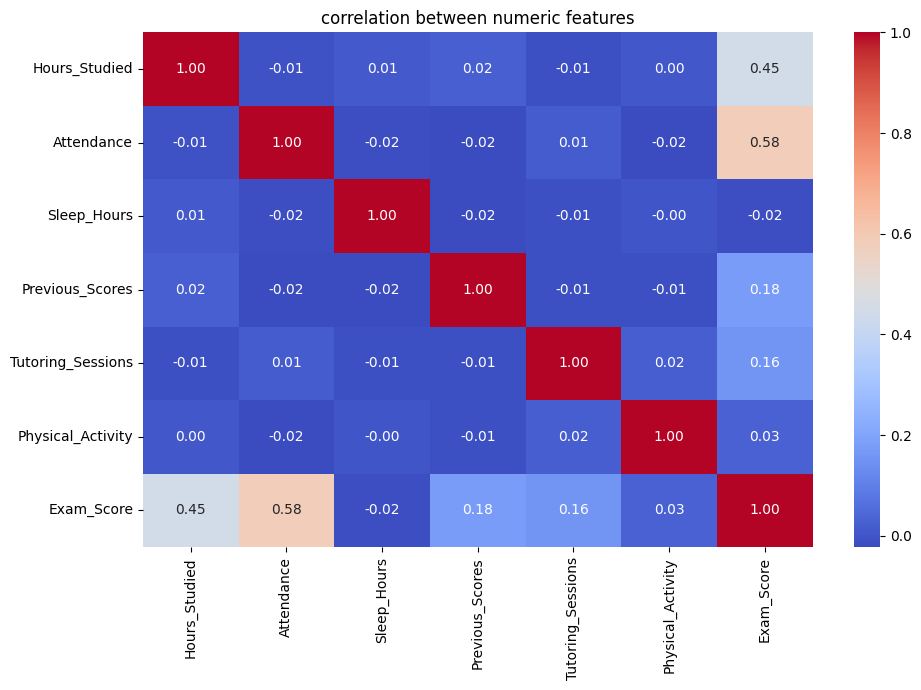

In [5]:
plt.figure(figsize=(10, 7))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('correlation between numeric features')
plt.tight_layout()
plt.show()

## 4. feature engineering

In [6]:
# deciding which columns to keep based on correlation with the target
df_eng = df.copy()

# temporarily encoding the categorical columns to measure correlation with exam score
df_temp = df_eng.copy()
for col in cat_cols:
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col].astype(str))

correlations = df_temp.corr()['Exam_Score'].drop('Exam_Score').sort_values(key=abs, ascending=False)

In [7]:
# now im going to drop columns that have almost no correlation with the target since they just add noise
# 0.02 will be the threshold meaning anything below that will be removed
low_corr_threshold = 0.02
low_corr_features = correlations[abs(correlations) < low_corr_threshold].index.tolist()
print('columns being dropped because their correlation \nis below', low_corr_threshold, ':', low_corr_features)

if low_corr_features:
    df_eng.drop(columns=low_corr_features, inplace=True, errors='ignore')
else:
    print('no columns dropped, all features have some correlation')

print('remaining shape:', df_eng.shape)

columns being dropped because their correlation 
is below 0.02 : ['Sleep_Hours', 'Motivation_Level', 'School_Type', 'Gender']
remaining shape: (6607, 16)


In [8]:
cat_remaining = df_eng.select_dtypes(include='object').columns.tolist()

ordinal_maps = {
    'Parental_Involvement': {'Low': 0, 'Medium': 1, 'High': 2},
    'Access_to_Resources': {'Low': 0, 'Medium': 1, 'High': 2},
    'Motivation_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Family_Income': {'Low': 0, 'Medium': 1, 'High': 2},
    'Teacher_Quality': {'Low': 0, 'Medium': 1, 'High': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Distance_from_Home': {'Near': 0, 'Moderate': 1, 'Far': 2},
    'Peer_Influence': {'Negative': 0, 'Neutral': 1, 'Positive': 2},
}

label_encode_cols = [col for col in cat_remaining if col not in ordinal_maps]

le = LabelEncoder()
for col in label_encode_cols:
    df_eng[col] = le.fit_transform(df_eng[col].astype(str))

for col, mapping in ordinal_maps.items():
    if col in df_eng.columns:
        df_eng[col] = df_eng[col].map(mapping)

In [9]:
# filling in any null values that may have come from the mapping step
null_counts = df_eng.isnull().sum()
if null_counts.any():
    print('some nulls found, filling them with the column median')
    df_eng.fillna(df_eng.median(numeric_only=True), inplace=True)
print('total null values remaining:', df_eng.isnull().sum().sum())

some nulls found, filling them with the column median
total null values remaining: 0


In [10]:
# separating the features from the target column
X = df_eng.drop(columns=['Exam_Score'])
y = df_eng['Exam_Score']

print('features shape:', X.shape)
print('target shape:', y.shape)
print('feature names:', list(X.columns))

features shape: (6607, 15)
target shape: (6607,)
feature names: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Previous_Scores', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home']


In [11]:
# split into train and test sets using 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('training set size:', X_train.shape)
print('test set size:', X_test.shape)

training set size: (5285, 15)
test set size: (1322, 15)


## 5. standardizing the data

In [12]:
# fitting the scaler only on the training data to avoid leaking test info
# then transforming both train and test using those same training statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')

['models/scaler.pkl']

## 6. training the models

im going to training three different models and then compare their performance at the end to decide which one to keep

### linear regression

In [13]:
# training a basic linear regression model using sklearn
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test = lr.predict(X_test_scaled)

lr_train_r2 = r2_score(y_train, y_pred_lr_train)
lr_test_r2 = r2_score(y_test, y_pred_lr_test)
lr_train_mse = mean_squared_error(y_train, y_pred_lr_train)
lr_test_mse = mean_squared_error(y_test, y_pred_lr_test)
lr_test_mae = mean_absolute_error(y_test, y_pred_lr_test)

print('linear regression results')
print('  train r2 :', round(lr_train_r2, 4))
print('  test r2  :', round(lr_test_r2, 4))
print('  train mse:', round(lr_train_mse, 4))
print('  test mse :', round(lr_test_mse, 4))
print('  test mae :', round(lr_test_mae, 4))

linear regression results
  train r2 : 0.7084
  test r2  : 0.7597
  train mse: 4.4857
  test mse : 3.3964
  test mae : 0.5539


### gradient descent using sgd regressor and plotting the loss curve

In [14]:
X_tr = X_train_scaled
X_te = X_test_scaled
y_tr = y_train.values
y_te = y_test.values

n_samples, n_features = X_tr.shape
learning_rate = 0.05
n_epochs = 200

weights = np.zeros(n_features)
bias = 0.0

train_losses = []
test_losses = []

for epoch in range(n_epochs):
    y_pred_tr = X_tr.dot(weights) + bias
    y_pred_te = X_te.dot(weights) + bias

    error = y_pred_tr - y_tr
    grad_w = (2 / n_samples) * X_tr.T.dot(error)
    grad_b = (2 / n_samples) * error.sum()

    weights -= learning_rate * grad_w
    bias -= learning_rate * grad_b

    train_losses.append(mean_squared_error(y_tr, y_pred_tr))
    test_losses.append(mean_squared_error(y_te, y_pred_te))

print('final training loss:', round(train_losses[-1], 4))
print('final test loss:', round(test_losses[-1], 4))

final training loss: 4.4857
final test loss: 3.3964


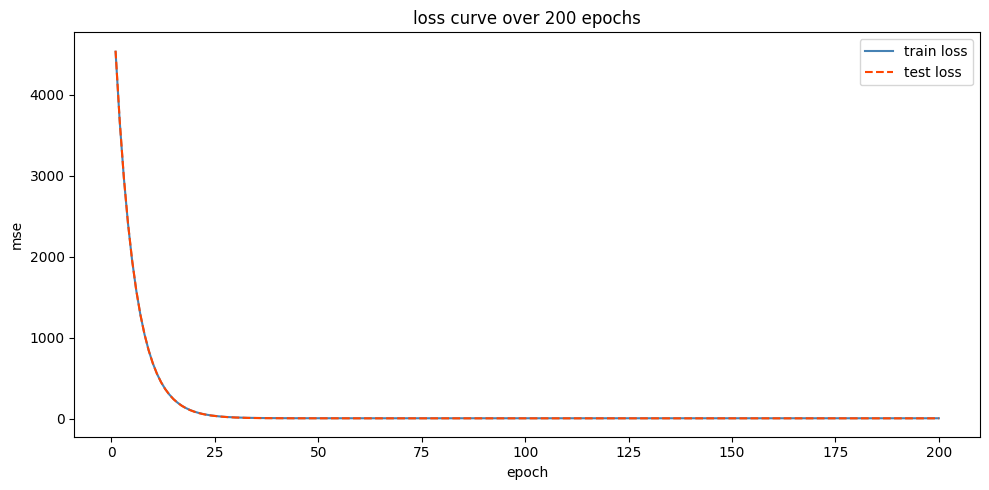

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label='train loss', color='steelblue')
plt.plot(range(1, n_epochs + 1), test_losses, label='test loss', color='orangered', linestyle='--')
plt.xlabel('epoch')
plt.ylabel('mse')
plt.title('loss curve over 200 epochs')
plt.legend()
plt.tight_layout()
plt.show()

### decision tree regressor

In [16]:
# training a decision tree with some limits on depth to stop it from overfitting
dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt_train = dt.predict(X_train_scaled)
y_pred_dt_test = dt.predict(X_test_scaled)

dt_train_r2 = r2_score(y_train, y_pred_dt_train)
dt_test_r2 = r2_score(y_test, y_pred_dt_test)
dt_train_mse = mean_squared_error(y_train, y_pred_dt_train)
dt_test_mse = mean_squared_error(y_test, y_pred_dt_test)
dt_test_mae = mean_absolute_error(y_test, y_pred_dt_test)

print('decision tree results')
print('  train r2 :', round(dt_train_r2, 4))
print('  test r2  :', round(dt_test_r2, 4))
print('  train mse:', round(dt_train_mse, 4))
print('  test mse :', round(dt_test_mse, 4))
print('  test mae :', round(dt_test_mae, 4))

decision tree results
  train r2 : 0.6589
  test r2  : 0.5524
  train mse: 5.2462
  test mse : 6.3273
  test mae : 1.511


### random forest regressor

In [17]:
# random forest trains many decision trees and averages
# their outputs which usually gives better results
rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf_train = rf.predict(X_train_scaled)
y_pred_rf_test = rf.predict(X_test_scaled)

rf_train_r2 = r2_score(y_train, y_pred_rf_train)
rf_test_r2 = r2_score(y_test, y_pred_rf_test)
rf_train_mse = mean_squared_error(y_train, y_pred_rf_train)
rf_test_mse = mean_squared_error(y_test, y_pred_rf_test)
rf_test_mae = mean_absolute_error(y_test, y_pred_rf_test)

print('random forest results')
print('  train r2 :', round(rf_train_r2, 4))
print('  test r2  :', round(rf_test_r2, 4))
print('  train mse:', round(rf_train_mse, 4))
print('  test mse :', round(rf_test_mse, 4))
print('  test mae :', round(rf_test_mae, 4))

random forest results
  train r2 : 0.7661
  test r2  : 0.6774
  train mse: 3.5971
  test mse : 4.5601
  test mae : 1.0943


## 7. comparing all three models

In [18]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train R2': [lr_train_r2, dt_train_r2, rf_train_r2],
    'Test R2': [lr_test_r2, dt_test_r2, rf_test_r2],
    'Train MSE': [lr_train_mse, dt_train_mse, rf_train_mse],
    'Test MSE': [lr_test_mse, dt_test_mse, rf_test_mse],
    'Test MAE': [lr_test_mae, dt_test_mae, rf_test_mae],
}).set_index('Model').round(4)
results

,Train R2,Test R2,Train MSE,Test MSE,Test MAE
Model,,,,,
Linear Regression,0.7084,0.7597,4.4857,3.3964,0.5539
Decision Tree,0.6589,0.5524,5.2462,6.3273,1.5110
Random Forest,0.7661,0.6774,3.5971,4.5601,1.0943


In [19]:
# picking the best model based on which one has the highest test r2 score
best_model_name = results['Test R2'].idxmax()
print('best performing model:', best_model_name)
print('test r2 score:', round(results.loc[best_model_name, 'Test R2'], 4))

best performing model: Linear Regression
test r2 score: 0.7597


## 8. scatter plot showing the regression line through the data

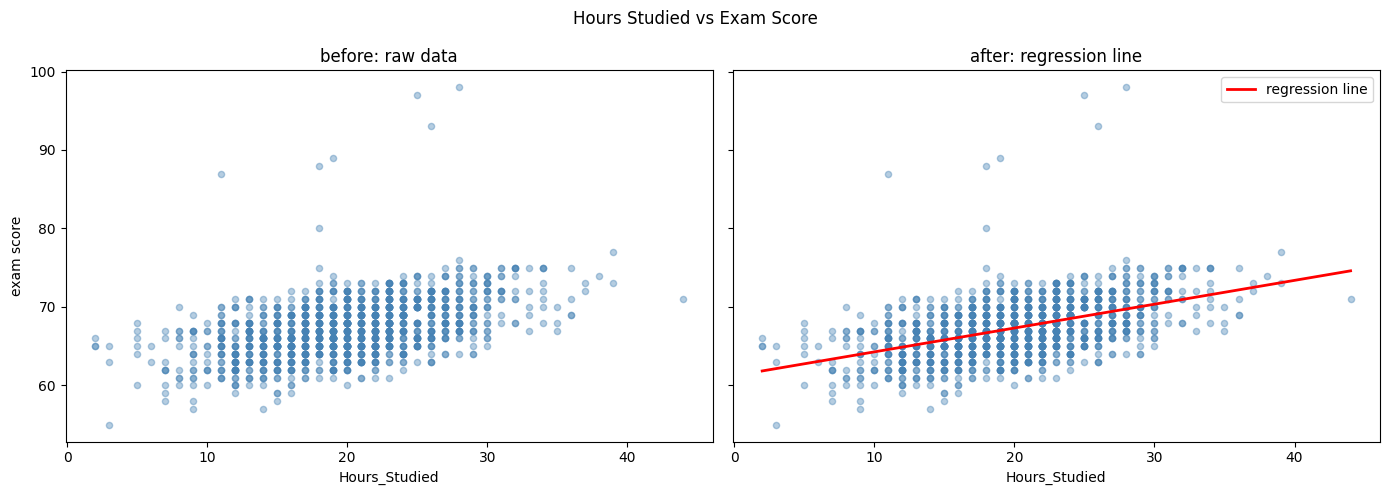

In [20]:
x_vis = X_test['Hours_Studied'].values
y_vis = y_test.values

z_vis = np.polyfit(x_vis, y_vis, 1)
p_vis = np.poly1d(z_vis)
x_sorted = np.linspace(x_vis.min(), x_vis.max(), 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(x_vis, y_vis, alpha=0.4, s=20, color='steelblue')
axes[0].set_title('before: raw data')
axes[0].set_xlabel('Hours_Studied')
axes[0].set_ylabel('exam score')

axes[1].scatter(x_vis, y_vis, alpha=0.4, s=20, color='steelblue')
axes[1].plot(x_sorted, p_vis(x_sorted), color='red', linewidth=2, label='regression line')
axes[1].set_title('after: regression line')
axes[1].set_xlabel('Hours_Studied')
axes[1].legend()

plt.suptitle('Hours Studied vs Exam Score')
plt.tight_layout()
plt.show()

## 9. saving the best model

In [21]:
model_map = {
    'Linear Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
}

best_model_obj = model_map[best_model_name]
joblib.dump(best_model_obj, 'models/best_model.pkl')
print('best model saved:', best_model_name)

best model saved: Linear Regression


## 10. making a prediction on one row from the test dataset

In [22]:
loaded_model = joblib.load('models/best_model.pkl')
loaded_scaler = joblib.load('models/scaler.pkl')

sample_row = X_test.iloc[[0]]
actual_score = y_test.iloc[0]

sample_scaled = loaded_scaler.transform(sample_row[list(X.columns)])
predicted_score = loaded_model.predict(sample_scaled)[0]

print('actual exam score   :', round(float(actual_score), 2))
print('predicted exam score:', round(float(predicted_score), 2))
print('difference          :', round(abs(float(actual_score) - float(predicted_score)), 2))

actual exam score   : 65.0
predicted exam score: 64.04
difference          : 0.96
